# Data preprocessing

Data Ingestion: Ingests four core Formula 1 CSV files (races, lap_times, pit_stops, starting_grid_positions) as distributed Spark DataFrames with automatic header extraction and schema inference.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
# Initialize Spark Session
spark = SparkSession.builder \
    .appName("F1_Data_Preprocessing") \
    .getOrCreate()

# 1. Load CSV datasets with schema inference
races = spark.read.csv('drive/MyDrive/data/f1db-races.csv', header=True, inferSchema=True)
lap_times = spark.read.csv('drive/MyDrive/data/f1db-races-lap-times.csv', header=True, inferSchema=True)
pit_stops = spark.read.csv('drive/MyDrive/data/f1db-races-pit-stops.csv', header=True, inferSchema=True)
grid = spark.read.csv('drive/MyDrive/data/f1db-races-starting-grid-positions.csv', header=True, inferSchema=True)

# 2. Rename columns in the base table (pit_stops) to prevent namespace collisions
pit_stops = pit_stops \
    .withColumnRenamed('time', 'pitTime') \
    .withColumnRenamed('timeMillis', 'pitTimeMillis') \
    .withColumnRenamed('positionDisplayOrder', 'pitStopPositionDisplayOrder') \
    .withColumnRenamed('positionNumber', 'pitStopPositionNumber') \
    .withColumnRenamed('positionText', 'pitStopPositionText')

# 3. Rename columns in grid dataset
grid = grid \
    .withColumnRenamed('time', 'gridTime') \
    .withColumnRenamed('timeMillis', 'gridTimeMillis') \
    .withColumnRenamed('positionDisplayOrder', 'gridPositionDisplayOrder') \
    .withColumnRenamed('positionNumber', 'gridPositionNumber') \
    .withColumnRenamed('positionText', 'gridPositionText')

# 4. Remove duplicate contextual columns from grid before joining
cols_to_remove = [
    'constructorId', 'engineManufacturerId', 'tyreManufacturerId',
    'year', 'round', 'driverNumber'
]
grid = grid.drop(*cols_to_remove)

# Join grid onto pit_stops using composite key
join_keys_grid = ['raceId', 'driverId']
merged_df = pit_stops.join(grid, on=join_keys_grid, how='left')

# 5. Prepare and clean races dataset
racesNew = races.withColumnRenamed('id', 'raceId')
racesNew = racesNew.drop(*cols_to_remove)

races_specific_drops = [
    'time', 'warmingUpDate', 'warmingUpTime', 'freePractice4Date',
    'freePractice4Time', 'qualifying1Date', 'qualifying1Time',
    'qualifying2Date', 'qualifying2Time', 'preQualifyingTime', 'preQualifyingDate'
]
racesNew = racesNew.drop(*races_specific_drops)

# 6. Final left join onto the race metadata
join_keys_races = ['raceId']
final_df = merged_df.join(racesNew, on=join_keys_races, how='left')

# Output shape (rows, columns)
print(f"Final Dataset Shape: ({final_df.count()}, {len(final_df.columns)})")

Final Dataset Shape: (22218, 53)


Structural Missingness Handling & Flagging: Encodes event absence into machine-readable binary flags (is_<event>_held) by evaluating null date entries, and subsequently replaces all remaining null values across the 12 session date and time columns with the 'Not Held' categorical placeholder using distributed subset imputation.

In [ ]:
events = [
    'freePractice1', 'freePractice2', 'freePractice3',
    'qualifying', 'sprintQualifying', 'sprintRace'
]
numerical_cols = ['scheduledLaps', 'scheduledDistance']
penalty_cols = ['gridPenalty', 'gridPenaltyPositions']
for event in events:
    date_col = f'{event}Date'
    flag_col = f'is_{event}_held'
    final_df = final_df.withColumn(
        flag_col,
        F.when(F.col(date_col).isNotNull(), 1).otherwise(0)
    )
schedule_cols = [f'{event}Date' for event in events] + [f'{event}Time' for event in events]
final_df = final_df.fillna('Not Held', subset=schedule_cols)
final_df = final_df.fillna(0, subset=numerical_cols + penalty_cols)


Dynamic Temporal Lookups & Out-of-Bounds Handling: Executes distributed left outer joins against deduplicated lap records matching relative prior (lap - 1) and settle-window (lap + N) offsets, followed by conditional Spark expressions (F.when) that generate binary indicator flags (is_prior_lap_missing, is_retired_after_pit) and inject descriptive placeholders ('No Prior Data', 'Retired') to capture first-lap anomalies and post-stop retirements without dropping rows.

In [ ]:
N = 2
#Compute target lookup lap numbers
final_df = final_df \
    .withColumn('lap_before', F.col('lap') - 1) \
    .withColumn('lap_after', F.col('lap') + N)

#Search and isolate unique rows by dropping duplicates
lap_times_unique = lap_times.dropDuplicates(['raceId', 'driverId', 'lap'])

#Create isolated lookup DataFrames for 'before' and 'after' laps
lap_lookup_before = lap_times_unique.select(
    F.col('raceId').alias('ref_raceId_b'),
    F.col('driverId').alias('ref_driverId_b'),
    F.col('lap').alias('ref_lap_b'),
    F.col('position').alias('raw_pos_b'),
    F.col('time').alias('raw_time_b'),
    F.col('timeMillis').alias('raw_timeMillis_b')
)

lap_lookup_after = lap_times_unique.select(
    F.col('raceId').alias('ref_raceId_a'),
    F.col('driverId').alias('ref_driverId_a'),
    F.col('lap').alias('ref_lap_a'),
    F.col('position').alias('raw_pos_a'),
    F.col('time').alias('raw_time_a'),
    F.col('timeMillis').alias('raw_timeMillis_a')
)

#Join dynamic lap lookups onto the main DataFrame
final_df = final_df.join(
    lap_lookup_before,
    (F.col('raceId') == F.col('ref_raceId_b')) &
    (F.col('driverId') == F.col('ref_driverId_b')) &
    (F.col('lap_before') == F.col('ref_lap_b')),
    how='left'
).join(
    lap_lookup_after,
    (F.col('raceId') == F.col('ref_raceId_a')) &
    (F.col('driverId') == F.col('ref_driverId_a')) &
    (F.col('lap_after') == F.col('ref_lap_a')),
    how='left'
)
# Handling Missing Laps and Retirements
#Evaluate Condition 1: First lap pit stop or missing prior data
mask_prior_issue = (
    (F.col('lap_before') == 0) |
    F.col('raw_pos_b').isNull() |
    F.col('raw_time_b').isNull() |
    F.col('raw_timeMillis_b').isNull()
)
raw_time_b_clean = F.when(mask_prior_issue, F.lit('00:00:00.000')).otherwise(F.col('raw_time_b').cast('string'))
colon_count_b = F.length(raw_time_b_clean) - F.length(F.replace(raw_time_b_clean, F.lit(':'), F.lit('')))
time_before_standardized = F.when(colon_count_b == 1, F.concat(F.lit("00:"), raw_time_b_clean)).otherwise(raw_time_b_clean)
final_df = final_df \
    .withColumn('is_prior_lap_missing', F.when(mask_prior_issue, 1).otherwise(0)) \
    .withColumn('position_before_pit', F.when(mask_prior_issue, F.lit(0)).otherwise(F.col('raw_pos_b').cast('int'))) \
    .withColumn('time_before_pit',time_before_standardized) \
    .withColumn('timeMillis_before_pit', F.when(mask_prior_issue, F.lit(0)).otherwise(F.col('raw_timeMillis_b').cast('int')))

#Evaluate Condition 2: Car retired or lost data after the pit stop
mask_after_issue = (
    F.col('raw_pos_a').isNull() |
    F.col('raw_time_a').isNull() |
    F.col('raw_timeMillis_a').isNull()
)

raw_time_a_clean = F.when(mask_after_issue, F.lit('00:00:00.000')).otherwise(F.col('raw_time_a').cast('string'))
colon_count_a = F.length(raw_time_a_clean) - F.length(F.replace(raw_time_a_clean, F.lit(':'), F.lit('')))
time_after_standardized = F.when(colon_count_a == 1, F.concat(F.lit("00:"), raw_time_a_clean)).otherwise(raw_time_a_clean)

final_df = final_df \
    .withColumn('is_retired_after_pit', F.when(mask_after_issue, 1).otherwise(0)) \
    .withColumn('position_after_pit', F.when(mask_after_issue, F.lit(0)).otherwise(F.col('raw_pos_a').cast('int'))) \
    .withColumn('time_after_pit', time_after_standardized) \
    .withColumn('timeMillis_after_pit', F.when(mask_after_issue, F.lit(0)).otherwise(F.col('raw_timeMillis_a').cast('int')))

#Drop temporary reference columns
temp_cols = [
    'ref_raceId_b', 'ref_driverId_b', 'ref_lap_b', 'raw_pos_b', 'raw_time_b', 'raw_timeMillis_b',
    'ref_raceId_a', 'ref_driverId_a', 'ref_lap_a', 'raw_pos_a', 'raw_time_a', 'raw_timeMillis_a'
]
final_df = final_df.drop(*temp_cols)


Evaluates the compound condition where a record simultaneously lacks prior lap context and suffers an immediate post-pit retirement (sensor anomalies or DNS artifacts), audits the affected row count via an active .count() aggregation, and filters the partition space using Spark's boolean inversion operator (~) without requiring index resetting.

In [ ]:
#Define the impossible condition expression using the engineered binary flags
impossible_condition = (F.col('is_prior_lap_missing') == 1) & (F.col('is_retired_after_pit') == 1)
#Count how many invalid rows match the drop condition for the data cleaning audit
dropped_count = final_df.filter(impossible_condition).count()
print(f"Removing {dropped_count} impossible pit stop records (No prior data + Immediate retirement).")
final_df = final_df.filter(~impossible_condition)

Removing 24 impossible pit stop records (No prior data + Immediate retirement).


It dynamically figures out exactly which driver was one position ahead just before the pit stop to capture their lap times, and then tracks that specific rival's performance a few laps later to see how the time gap changed—all while smoothly ignoring invalid text placeholders (like 'No Prior Data') by converting them into safe, empty null values.

Flow:
* get the lap_before
* get position_before_pit
add +1 to position_before_pit to get the rivalry's position.
* go to the lap times and get the row according to, raceID, lap and position. get the driver ID and the number.
* then get the rivalry's lap time and timeMS. (this is before piting)
* get the rivalry's next lap's time, time MS and position according to same race ID, previous lap + 1, and driver ID (rival's).

In [ ]:
N = 2

#Safely calculate the rival's position
final_df = final_df \
    .withColumn('rival_position', F.col('position_before_pit').cast('int') - 1) \
    .withColumn('rival_next_lap', F.col('lap_before') + N)

lap_times_pos = lap_times.dropDuplicates(['raceId', 'lap', 'position'])

# Prepare reference lookup DataFrame
lap_lookup_before = lap_times_pos.select(
    F.col('raceId').alias('ref_raceId_b'),
    F.col('lap').alias('ref_lap_b'),
    F.col('position').alias('ref_pos_b'),
    F.col('driverId').alias('rival_driverId'),
    F.col('driverNumber').alias('rival_driverNumber'),
    F.col('time').alias('rival_time_before_pit'),
    F.col('timeMillis').alias('rival_timeMillis_before_pit')
)

# Assign rival's 'before pit' variables via distributed join
final_df = final_df.join(
    lap_lookup_before,
    (F.col('raceId') == F.col('ref_raceId_b')) &
    (F.col('lap_before') == F.col('ref_lap_b')) &
    (F.col('rival_position') == F.col('ref_pos_b')),
    how='left'
)
#Get Rival Data (After Pit)
lap_times_driver = lap_times.dropDuplicates(['raceId', 'driverId', 'lap'])

#Prepare reference lookup DataFrame
lap_lookup_after = lap_times_driver.select(
    F.col('raceId').alias('ref_raceId_a'),
    F.col('driverId').alias('ref_driverId_a'),
    F.col('lap').alias('ref_lap_a'),
    F.col('position').alias('rival_position_after_pit'),
    F.col('time').alias('rival_time_after_pit'),
    F.col('timeMillis').alias('rival_timeMillis_after_pit')
)

#Assign rival's 'after pit' variables using the newly discovered rival_driverId
final_df = final_df.join(
    lap_lookup_after,
    (F.col('raceId') == F.col('ref_raceId_a')) &
    (F.col('rival_driverId') == F.col('ref_driverId_a')) &
    (F.col('rival_next_lap') == F.col('ref_lap_a')),
    how='left'
)

#Clean up temporary reference columns used for the join logic
temp_cols = [
    'ref_raceId_b', 'ref_lap_b', 'ref_pos_b',
    'ref_raceId_a', 'ref_driverId_a', 'ref_lap_a',
    'rival_next_lap'
]
final_df = final_df.drop(*temp_cols)

It identifies instances where a driver has no rival to chase (meaning they are at the very back of the pack), creates a simple 1 or 0 tracking flag for the machine learning models, and fills all the empty rival-related cells with the text 'No Rival (Last Position)' so the dataset doesn't break due to missing values.

In [ ]:
rival_cols_int = [
    'rival_driverNumber',
    'rival_timeMillis_before_pit',
    'rival_position_after_pit',
    'rival_timeMillis_after_pit'
]

rival_cols_time = [
    'rival_time_before_pit',
    'rival_time_after_pit'
]

rival_cols_str = [
    'rival_driverId'
]

mask_last_position = F.col('rival_driverId').isNull()

final_df = final_df.withColumn(
    'is_last_position',
    F.when(mask_last_position, 1).otherwise(0)
)

for c in rival_cols_int:
    final_df = final_df.withColumn(
        c,
        F.when(mask_last_position, F.lit(0))
        .otherwise(F.col(c).cast('int'))
    )

for c in rival_cols_str:
    final_df = final_df.withColumn(
        c,
        F.when(mask_last_position, F.lit('No Rival (Last Position)'))
        .otherwise(F.col(c).cast('string'))
    )

for c in rival_cols_time:
    is_invalid_time = mask_last_position

    cleaned_col = F.when(is_invalid_time, F.lit('00:00:00.000')).otherwise(F.col(c).cast('string'))

    # Count colons to standardize varying duration formats
    colon_count = F.length(cleaned_col) - F.length(F.replace(cleaned_col, F.lit(':'), F.lit('')))

    # Dynamic padding: 0 colons -> 00:00:SS.ms, 1 colon -> 00:MM:SS.ms, 2 colons -> unchanged
    padded_col = (
        F.when(colon_count == 0, F.concat(F.lit("00:00:"), cleaned_col))
         .when(colon_count == 1, F.concat(F.lit("00:"), cleaned_col))
         .otherwise(cleaned_col)
    )

    final_df = final_df.withColumn(c, padded_col)

It spots situations where a driver's specific rival drops out of the race just after the pit stop, creates a simple 1 or 0 flag to mark this sudden drop in track pressure, and explicitly fills the missing timing data with 'Rival Retired' to keep the dataset clean for your "Coursework related to data science module. I have to create a report and use tools for this. I have to select a dataset also." project without artificially distorting the physical reality of the race.

In [ ]:
mask_rival_retired = (
    (F.col('rival_driverId') != 'No Rival (Last Position)') &
    F.col('rival_driverId').isNotNull() &
    F.col('rival_time_after_pit').isNull()
)

final_df = final_df.withColumn(
    'is_rival_retired_after_pit',
    F.when(mask_rival_retired, 1).otherwise(0)
)

rival_after_cols_int = [
    'rival_position_after_pit',
    'rival_timeMillis_after_pit'
]

for c in rival_after_cols_int:
    final_df = final_df.withColumn(
        c,
        F.when(mask_rival_retired, F.lit(0))
        .otherwise(F.col(c).cast('int'))
    )

time standard converter (both empty and non empty) for  time_before_pit, time_after_pit, rival_time_before_pit, rival_time_after_pit, gridTime

In [ ]:
from pyspark.sql import functions as F

# 1. Define all targeted time columns across the dataset
all_time_cols = [
    'time_before_pit',
    'time_after_pit',
    'rival_time_before_pit',
    'rival_time_after_pit',
    'gridTime'
]

# 2. Loop through and standardize only the existing values
for c in all_time_cols:

    existing_col = F.col(c).cast('string')

    colon_count = F.length(existing_col) - F.length(F.replace(existing_col, F.lit(':'), F.lit('')))

    padded_col = (
        F.when(colon_count == 0, F.concat(F.lit("00:00:"), existing_col))
         .when(colon_count == 1, F.concat(F.lit("00:"), existing_col))
         .otherwise(existing_col)
    )

    final_df = final_df.withColumn(c, padded_col)

It calculates the physical time difference between the driver and their rival right before and after the pit stop by safely forcing the data into numbers (which turns descriptive text into safe, empty values), generating the primary target variable needed for the predictive modeling in your "Coursework related to data science module. I have to create a report and use tools for this. I have to select a dataset also." project.

It calculates the physical time difference between the driver and their rival right before and after the pit stop by safely forcing the data into numbers (which turns descriptive text into safe, empty values)

In [ ]:
final_df = final_df \
    .withColumn('rival_gap_before_pit_ms',
                F.col('timeMillis_before_pit').cast('double') - F.col('rival_timeMillis_before_pit').cast('double')) \
    .withColumn('rival_gap_after_pit_ms',
                F.col('timeMillis_after_pit').cast('double') - F.col('rival_timeMillis_after_pit').cast('double'))

final_df = final_df \
    .withColumn('rival_gap_before_pit_ms',
                F.col('timeMillis_before_pit').cast('double') - F.col('rival_timeMillis_before_pit').cast('double')) \
    .withColumn('rival_gap_after_pit_ms',
                F.col('timeMillis_after_pit').cast('double') - F.col('rival_timeMillis_after_pit').cast('double'))

Tracking Tire Age (Stint Lengths): It replaces the slow, row-by-row Pandas search with optimized distributed Window functions and relational joins to calculate exactly how many laps both the driver and their rival have been running since their last pit stop (or the race start).

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# Driver Stint Length
# Create a window partitioned by race and driver, ordered chronologically by stop
driver_window = Window.partitionBy('raceId', 'driverId').orderBy('stop')

final_df = final_df.withColumn(
    'driver_stint_length',
    F.coalesce(F.col('lap') - F.lag('lap').over(driver_window), F.col('lap')).cast('int')
)

# Rival Stint Length & Flagging
invalid_flags = ['No Rival (Last Position)', 'Retired', 'No Prior Data', 'Rival Retired']
valid_rival_cond = F.col('rival_driverId').isNotNull() & (~F.col('rival_driverId').isin(invalid_flags))

# Create a historical ledger of pit stops
pit_ledger = final_df.select(
    F.col('raceId').alias('ledger_raceId'),
    F.col('driverId').alias('ledger_driverId'),
    F.col('lap').alias('ledger_lap')
)

# Join the ledger to find the rival's past pit stops, then aggregate to find the maximum (most recent) lap
rival_max_lap = final_df.join(
    pit_ledger,
    (F.col('raceId') == F.col('ledger_raceId')) &
    (F.col('rival_driverId') == F.col('ledger_driverId')) &
    (F.col('lap') > F.col('ledger_lap')),
    how='left'
).groupBy('raceId', 'driverId', 'lap').agg(
    F.max('ledger_lap').alias('rival_last_pit_lap')
)

# Join the aggregated max lap back to the main DataFrame
final_df = final_df.join(rival_max_lap, on=['raceId', 'driverId', 'lap'], how='left')

# Calculate the rival stint length and handle missing data flags
final_df = final_df \
    .withColumn(
        'rival_stint_length',
        F.when(~valid_rival_cond, F.lit(0))
         .otherwise((F.col('lap') - F.coalesce(F.col('rival_last_pit_lap'), F.lit(0))).cast('int'))
    ) \
    .withColumn(
        'is_rival_stint_missing',
        F.when(F.col('rival_stint_length') == 0, 1).otherwise(0)
    ) \
    .drop('rival_last_pit_lap')

Tracking Tire Wear (Degradation Slope): It cleans out unusually slow outlier laps (like safety cars) and leverages Spark's distributed applyInPandas capability to run the sliding-window mathematical linear regression across all drivers simultaneously.

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, IntegerType, StringType, DoubleType
import pandas as pd
import numpy as np

# Clean and prepare the lap times dataset globally
lap_times = lap_times.withColumn('time_numeric', F.col('timeMillis').cast('double'))

# Filter out extreme outliers (> 4 minutes) globally
max_time_ms = 240000
clean_laps = lap_times.filter(
    F.col('time_numeric').isNotNull() &
    (F.col('time_numeric') <= max_time_ms)
).withColumn('time_sec', F.col('time_numeric') / 1000.0)

# Define the output schema for the grouped Pandas UDF
slope_schema = StructType([
    StructField("raceId", IntegerType(), True),
    StructField("driverId", StringType(), True),
    StructField("driverNumber", IntegerType(), True),
    StructField("lap", IntegerType(), True),
    StructField("driver_degradation_slope_sec", DoubleType(), True)
])

# Define the vectorized function to compute slope over a rolling group in Spark
def fast_slope_pdf(pdf: pd.DataFrame) -> pd.DataFrame:
    # Ensure sequential chronological order within the partition
    pdf = pdf.sort_values('lap')
    x = pdf['lap'].values
    y = pdf['time_sec'].values

    slopes = []
    for i in range(len(y)):
        if i < 1:
            slopes.append(np.nan)
            continue

        start_idx = max(0, i - 4)
        x_window = x[start_idx : i + 1]
        y_window = y[start_idx : i + 1]

        if len(y_window) < 2:
            slopes.append(np.nan)
            continue

        try:
            s = float(np.polyfit(x_window, y_window, 1)[0])
            slopes.append(s)
        except:
            slopes.append(np.nan)

    pdf['driver_degradation_slope_sec'] = slopes
    return pdf[['raceId', 'driverId', 'driverNumber', 'lap', 'driver_degradation_slope_sec']]

# Apply group-wise calculation efficiently using Spark's applyInPandas
print("Calculating rolling slopes globally...")
calculated_laps = clean_laps.groupBy('raceId', 'driverId', 'driverNumber').applyInPandas(
    fast_slope_pdf,
    schema=slope_schema
)

# Drop duplicates based on the expanded composite key to prevent partition explosion
calculated_laps_unique = calculated_laps.dropDuplicates(['raceId', 'driverId', 'driverNumber', 'lap'])

# Drop the column if it already exists to prevent ambiguity during re-runs
if 'driver_degradation_slope_sec' in final_df.columns:
    final_df = final_df.drop('driver_degradation_slope_sec')

# Join the calculated slopes onto final_df
final_df = final_df.join(
    calculated_laps_unique,
    on=['raceId', 'driverId', 'driverNumber', 'lap'],
    how='left'
)
final_df = final_df.withColumn(
    'driver_degradation_slope_sec',
    F.coalesce(F.col('driver_degradation_slope_sec').cast('string'), F.lit('Insufficient Data'))
)
# Define the condition for missing or insufficient slope data
mask_missing_slope = F.col('driver_degradation_slope_sec').isNull() | (F.col('driver_degradation_slope_sec') == 'Insufficient Data')

# Add the binary flag and structurally impute 0.0
final_df = final_df.withColumn(
    'is_slope_missing',
    F.when(mask_missing_slope, 1).otherwise(0)
).withColumn(
    'driver_degradation_slope_sec',
    F.when(mask_missing_slope, 0.0)
    .otherwise(F.col('driver_degradation_slope_sec').cast('double'))
)

Calculating rolling slopes globally...


Tracking Race Progress: It calculates exactly how many positions a driver has gained or lost since the start of the race by subtracting their current track position from their starting grid slot

In [ ]:
grid_pos_num = F.col('gridPositionNumber').cast('double')

current_pos_num = F.when(
    F.col('is_prior_lap_missing') == 0,
    F.col('position_before_pit').cast('double')
).otherwise(F.lit(None))

# Execute the calculation (Grid - Current)
final_df = final_df.withColumn('positions_gained_lost', grid_pos_num - current_pos_num)

# Handle missing data structurally (Binary Flagging + Constant Imputation)
final_df = final_df \
    .withColumn(
        'is_positions_gained_missing',
        F.when(F.col('positions_gained_lost').isNull(), 1).otherwise(0)
    ) \
    .withColumn(
        'positions_gained_lost',
        F.coalesce(F.col('positions_gained_lost'), F.lit(0.0))
    )

Tracking Race Progress: It mathematically calculates how many positions a driver has gained or lost since the start of the race

In [ ]:
# PySpark's .cast('double') automatically turns non-numeric strings into nulls.
grid_pos_num = F.col('gridPositionNumber').cast('double')

current_pos_num = F.when(
    F.col('is_prior_lap_missing') == 0,
    F.col('position_before_pit').cast('double')
).otherwise(F.lit(None))

# Execute the calculation (Grid - Current)
final_df = final_df.withColumn('positions_gained_lost', grid_pos_num - current_pos_num)

# Handle missing data structurally (Binary Flagging + Constant Imputation)
final_df = final_df \
    .withColumn(
        'is_positions_gained_missing',
        F.when(F.col('positions_gained_lost').isNull(), 1).otherwise(0)
    ) \
    .withColumn(
        'positions_gained_lost',
        F.coalesce(F.col('positions_gained_lost'), F.lit(0.0))
    )

Measuring Track Traffic: It calculates exactly how many cars are actively running on the track during that specific lap by counting the driver records in the lap times data.

In [ ]:
# Aggregate the count of drivers per raceId and lap directly from the lap_times dataset
lap_driver_counts = lap_times.groupBy('raceId', 'lap').agg(
    F.count('*').alias('drivers_on_lap_count')
)

# Map the counts into final_df using a distributed left join instead of a dictionary lookup
final_df = final_df.join(lap_driver_counts, on=['raceId', 'lap'], how='left')

# Fill any missing values with 0 and enforce integer formatting
final_df = final_df.withColumn(
    'drivers_on_lap_count',
    F.coalesce(F.col('drivers_on_lap_count'), F.lit(0)).cast('int')
)

Final Data Cleaning & Formatting: It drops unneeded metadata columns to save memory.

Isolating the Target Variable: It calculates the final answer for your machine learning model to predict.

Auditing and Removing Duplicates: It uses a distributed Window function to hunt down and export every instance of duplicate pit stops.

In [ ]:
#Drop columns safely (PySpark natively ignores columns that don't exist in the DataFrame)
columns_to_drop = ['sprintQualifyingFormat', 'circuitLayoutId', 'pitStopPositionText', 'grandPrixId']
final_df = final_df.drop(*columns_to_drop)

cols_group_1 = [
    'rival_gap_before_pit_ms',
    'rival_gap_after_pit_ms',
    'rival_stint_length'
]

cols_group_int = [
    'rival_timeMillis_before_pit',
    'rival_position_after_pit',
    'rival_timeMillis_after_pit',
    'position_before_pit',
    'timeMillis_before_pit',
    'position_after_pit',
    'timeMillis_after_pit'
]

cast_cols = set(cols_group_1 + cols_group_int)
# Execute all transformations in a single projection to bypass Catalyst optimization bottlenecks
exprs = [
    F.coalesce(F.expr(f"try_cast(`{c}` as int)"), F.lit(0)).alias(c) if c in cast_cols else F.col(c)
    for c in final_df.columns
]
final_df = final_df.select(*exprs)#Time Format Conversion Group
# cols_group_time = [
#     'rival_time_before_pit',
#     'rival_time_after_pit',
#     'time_before_pit',
#     'time_after_pit'
# ]


#String Identifier Group
# cols_group_str = [
#     'rival_driverNumber'
# ]

#Replace string artifacts with '0' (or null) while retaining string format
# for c in cols_group_str:
#     final_df = final_df.withColumn(
#         c,
#         F.when(F.col(c).isin(string_artifacts), '0').otherwise(F.col(c).cast('string'))
#     )

# Calculate the net time-gap change (Target Variable)
final_df = final_df.withColumn(
    'target_gap_change_ms',
    F.col('rival_gap_before_pit_ms') - F.col('rival_gap_after_pit_ms')
)


# drop rows where the change is beyond a realistic threshold
THRESHOLD_MS = 4 * 60 * 1000
final_df = final_df.filter(F.abs(F.col('target_gap_change_ms')) <= THRESHOLD_MS)

#remove duplication
# Identify and isolate ALL instances of the duplicates for auditing (keep=False equivalent)
final_df = final_df.cache()
original_count = final_df.count()

dup_window = Window.partitionBy('raceId', 'driverId', 'stop')
duplicate_audit_df = final_df.withColumn('dup_count', F.count('*').over(dup_window))\
                             .filter(F.col('dup_count') > 1)\
                             .drop('dup_count')\
                             .cache()

# Filter to keep only rows that appear more than once, then drop the temporary count column
# duplicate_audit_df = audit_df.filter(F.col('dup_count') > 1).drop('dup_count')
# duplicate_audit_df = duplicate_audit_df.cache()

export_path = 'duplicate_pit_stops_audit'
duplicate_audit_df.coalesce(1).orderBy('raceId', 'driverId', 'stop').write.csv(export_path, header=True, mode='overwrite')
audit_count = duplicate_audit_df.count()

# Drop duplicates on main DataFrame
final_df = final_df.dropDuplicates(['raceId', 'driverId', 'stop'])
cleaned_count = final_df.count()

print(f"Audit Complete: {audit_count} overlapping rows exported to '{export_path}'")
print(f"Dataset Cleaned: Removed {original_count - cleaned_count} redundant records from final_df.")

Audit Complete: 52 overlapping rows exported to 'duplicate_pit_stops_audit'
Dataset Cleaned: Removed 26 redundant records from final_df.


Binery flags for different columns (girdPenalty,gridPositionNumber,qualification) and rival positon null filling.

In [ ]:
import pyspark.sql.functions as F

columns = final_df.columns

# 1. Flag special grid penalty codes before stripping them
is_special_condition = ~F.col('gridPenalty').cast('string').rlike(r'^-?\d+$')
final_df = final_df.withColumn('gridPenaltyIsSpecialCode', F.when(is_special_condition, 1).otherwise(0))

# "Empty the letters first" using regex (removes everything except digits and minus signs)
clean_penalty = F.regexp_replace(F.col('gridPenalty').cast('string'), r'[^\d-]', '')

# Convert empty strings to null before casting to prevent malformed string errors
clean_penalty_safe = F.when(clean_penalty == '', None).otherwise(clean_penalty)

final_df = final_df.withColumn(
    'gridPenalty',
    F.coalesce(clean_penalty_safe.cast('int'), F.lit(0))
)

# 2. Flag Pit Lane starts (only if the column still exists)
if 'gridPositionText' in columns:
    final_df = final_df \
        .withColumn('isPitLaneStart', F.when(F.col('gridPositionText') == 'PL', 1).otherwise(0)) \
        .withColumn('gridPositionNumber', F.coalesce(F.expr("try_cast(gridPositionNumber as double)"), F.lit(0.0))) \
        .drop('gridPositionText')

# 3. Create binary flags for qualification status (only if the column still exists)
if 'qualificationPositionText' in columns:
    quali_codes = ['NC', 'EX', 'DSQ', 'DNF', 'DNS']
    for code in quali_codes:
        final_df = final_df.withColumn(
            f'quali_{code}',
            F.when(F.col('qualificationPositionText') == code, 1).otherwise(0)
        )

    final_df = final_df \
        .withColumn('qualificationPositionNumber', F.coalesce(F.expr("try_cast(qualificationPositionNumber as double)"), F.lit(0.0))) \
        .drop('qualificationPositionText')

# 4. Clean rival_position
final_df = final_df.withColumn(
    'rival_position',
    F.coalesce(F.expr("try_cast(rival_position as int)"), F.lit(0))
)

Removing Structural Clutter: It permanently deletes a batch of irrelevant identifier columns and mostly empty scheduling data

In [ ]:
# Define the list of columns to remove
columns_to_drop = [
    'freePractice1Date', 'freePractice1Time',
    'freePractice2Date', 'freePractice2Time',
    'freePractice3Date', 'freePractice3Time',
    'qualifyingDate', 'qualifyingTime',
    'sprintQualifyingDate', 'sprintQualifyingTime',
    'sprintRaceDate', 'sprintRaceTime',
    'circuitId', 'driversChampionshipDecider', 'constructorsChampionshipDecider'
]

# Drop the columns using the unpack operator (*) which PySpark requires for lists
final_df = final_df.drop(*columns_to_drop)

Converting categorical F1 race variables into machine-readable numeric vectors (One-Hot Encoding) and normalizing unstructured lap time strings into a standardized computational metric (total seconds) for model training.

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.types import StringType
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml import Pipeline

# One-Hot Encoding
categorical_columns = ['qualifyingFormat', 'circuitType', 'direction', 'tyreManufacturerId']
prefix_list = ['qualifyingFormat', 'circuitType', 'direction', 'tyre']

# Spark requires indexing strings to numerics first, then encoding to SparseVectors
indexers = [
    StringIndexer(inputCol=col, outputCol=f"{col}_index", handleInvalid="keep")
    for col in categorical_columns
]
encoder = OneHotEncoder(
    inputCols=[f"{col}_index" for col in categorical_columns],
    outputCols=[f"{prefix}_vec" for prefix in prefix_list]
)

pipeline = Pipeline(stages=indexers + [encoder])
final_df = pipeline.fit(final_df).transform(final_df)

# Drop intermediate index columns
final_df = final_df.drop(*[f"{col}_index" for col in categorical_columns])

# # ---------------------------------------------------------
# # 2. Grid Time Conversion
# # ---------------------------------------------------------
# # Handle missing values
# final_df = final_df.fillna({'gridTime': '00:00:00.000'})

# # Standardize F1 time strings dynamically using a User Defined Function (UDF)
# @F.udf(returnType=StringType())
# def standardize_f1_time(time_str):
#     if not time_str:
#         return "00:00:00.000"
#     colons = time_str.count(':')
#     if colons == 0:
#         return f"00:00:{time_str}"
#     elif colons == 1:
#         return f"00:{time_str}"
#     return time_str

# final_df = final_df.withColumn('gridTime', standardize_f1_time(F.col('gridTime')))

# Convert standardized string (HH:MM:SS.ms) to total computational seconds
final_df = final_df.withColumn(
    'gridTime_clean',
    F.when((F.col('gridTime').isNull()) | (F.trim(F.col('gridTime')) == ''), '00:00:00.000')
     .otherwise(F.col('gridTime'))
)

final_df = final_df.withColumn(
    'gridTime_seconds',
    F.expr("""
        coalesce(try_cast(split(gridTime_clean, ':')[0] as int), 0) * 3600 +
        coalesce(try_cast(split(gridTime_clean, ':')[1] as int), 0) * 60 +
        coalesce(try_cast(split(gridTime_clean, ':')[2] as double), 0.0)
    """)
).drop('gridTime_clean')

missing column engineering: is_gap_before_missing, is_gap_after_missing, pit_lane_traffic

In [ ]:
import pyspark.sql.functions as F
from pyspark.sql.window import Window

# Calculate Pit Lane Traffic (3-Lap Sliding Window)
lap_counts = final_df.groupBy('raceId', 'lap').agg(F.count('*').alias('stops_on_lap'))
final_df = final_df.join(lap_counts, on=['raceId', 'lap'], how='left')
traffic_window = Window.partitionBy('raceId').orderBy('lap').rangeBetween(-1, 1)

final_df = final_df.withColumn(
    'pit_lane_traffic',
    (F.sum('stops_on_lap').over(traffic_window) - F.lit(1)).cast('int')
).drop('stops_on_lap')

# Flagging and Imputing Missing Gaps (Before Pit)
mask_gap_before_missing = (F.col('timeMillis_before_pit') == 0) | (F.col('rival_timeMillis_before_pit') == 0)

final_df = final_df \
    .withColumn('is_gap_before_missing', F.when(mask_gap_before_missing, 1).otherwise(0)) \
    .withColumn(
        'rival_gap_before_pit_ms',
        F.when(mask_gap_before_missing, F.lit(0))
         .otherwise(F.col('rival_gap_before_pit_ms').cast('int'))
    )

# Flagging and Imputing Missing Gaps (After Pit)
mask_gap_after_missing = (F.col('timeMillis_after_pit') == 0) | (F.col('rival_timeMillis_after_pit') == 0)

final_df = final_df \
    .withColumn('is_gap_after_missing', F.when(mask_gap_after_missing, 1).otherwise(0)) \
    .withColumn(
        'rival_gap_after_pit_ms',
        F.when(mask_gap_after_missing, F.lit(0))
         .otherwise(F.col('rival_gap_after_pit_ms').cast('int'))
    )

Empty or null value handling for rival_time_after_pit, rival_time_before_pit with the same format.

In [ ]:
import pyspark.sql.functions as F

rival_time_cols = ['rival_time_before_pit', 'rival_time_after_pit']
invalid_time_strings = ['No Rival (Last Position)', 'Rival Retired', 'No Prior Data', 'No Rival Data']

for c in rival_time_cols:
    mask_missing = (
        F.col(c).isNull() |
        (F.trim(F.col(c).cast('string')) == '') |
        F.col(c).cast('string').isin(invalid_time_strings)
    )

    raw_time_clean = F.when(mask_missing, F.lit('00:00:00.000')).otherwise(F.col(c).cast('string'))

    colon_count = F.length(raw_time_clean) - F.length(F.replace(raw_time_clean, F.lit(':'), F.lit('')))
    time_standardized = (
        F.when(colon_count == 0, F.concat(F.lit("00:00:"), raw_time_clean))
         .when(colon_count == 1, F.concat(F.lit("00:"), raw_time_clean))
         .otherwise(raw_time_clean)
    )

    final_df = final_df.withColumn(c, time_standardized)

In [ ]:
from pyspark.ml.functions import vector_to_array
import pyspark.sql.functions as F
import uuid
vector_cols = ['qualifyingFormat_vec', 'circuitType_vec', 'direction_vec', 'tyre_vec']

for col_name in vector_cols:
    final_df = final_df.withColumn(col_name, vector_to_array(F.col(col_name)).cast("string"))

spark.conf.set("spark.sql.ansi.enabled", "false")
random_filename = f'{uuid.uuid4()}.csv'
final_df.coalesce(1).write.csv(random_filename, header=True, mode="overwrite")

# Illustrations

Apache Parquet Serialization

In [ ]:
import uuid

export_path = f'f1_pit_stops_processed_{uuid.uuid4()}.parquet'
final_df.write.parquet(export_path, mode="overwrite")
print(f"Dataset securely serialized to Parquet: {export_path}")

Dataset securely serialized to Parquet: f1_pit_stops_processed_6d67ab84-404f-47eb-ab86-8ad4d257b633.parquet


Illustrations of original preprocessed data

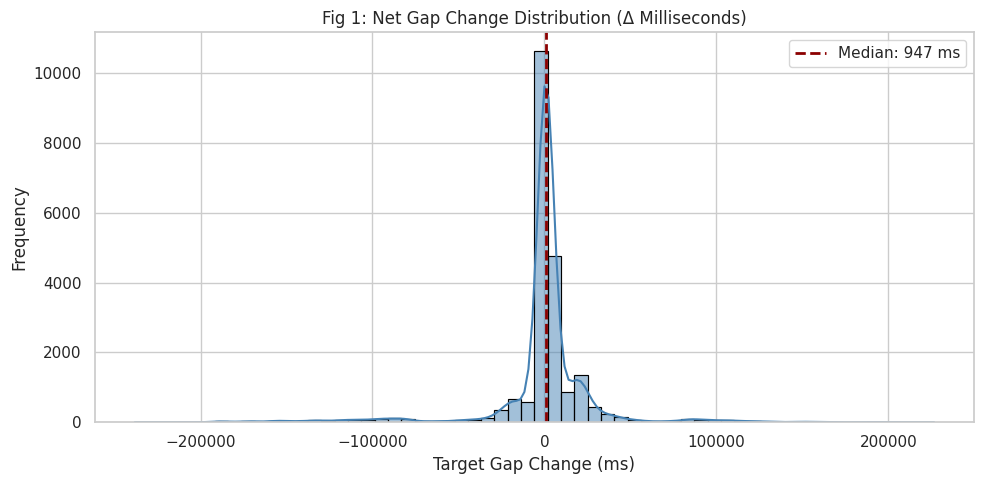

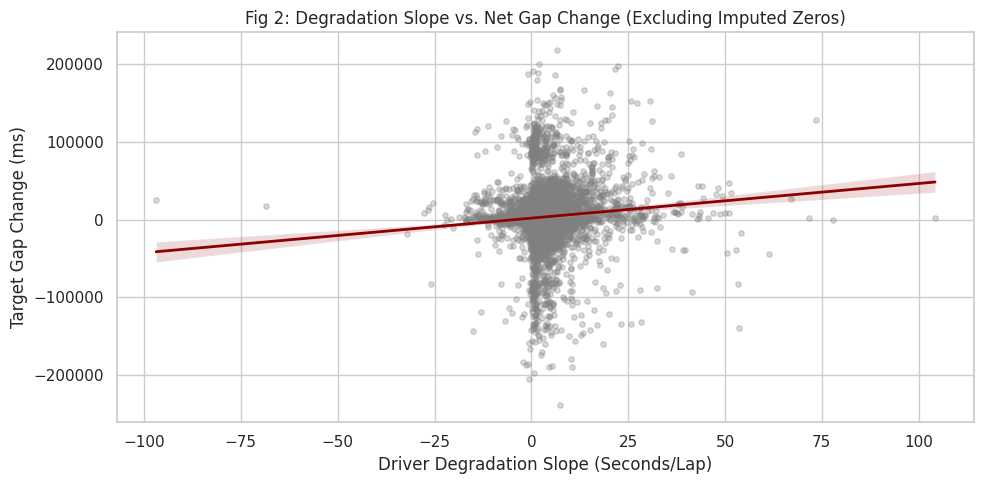

/tmp/ipykernel_57120/3818422726.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=fig3_data.sort_values('traffic_category'), x='traffic_category', y='target_gap_change_ms',


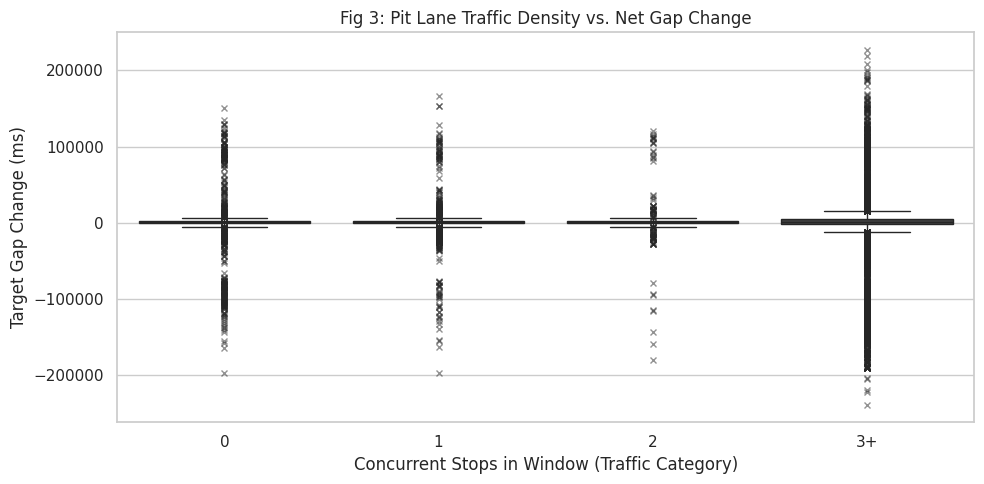

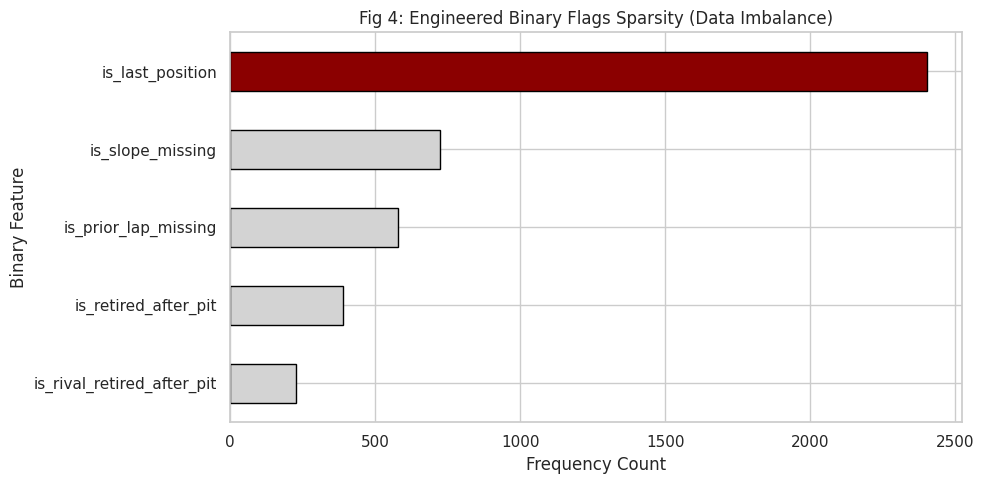

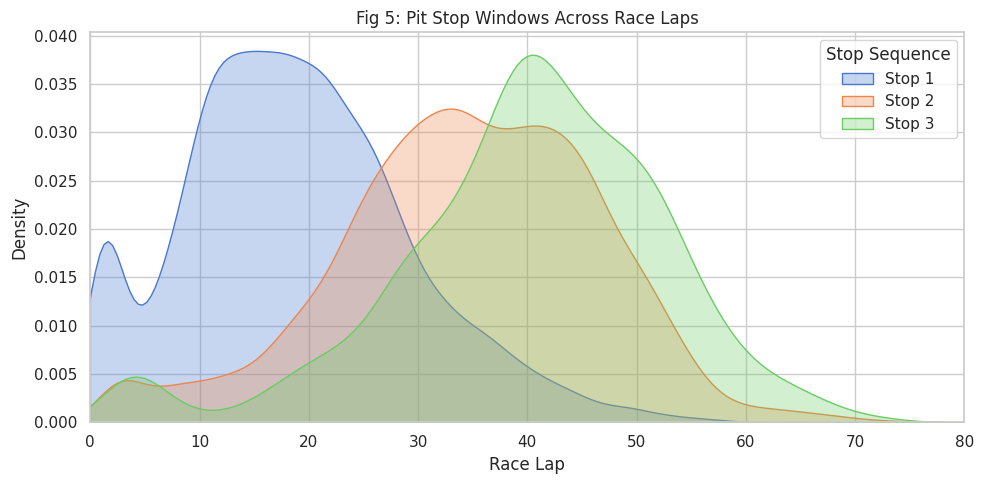

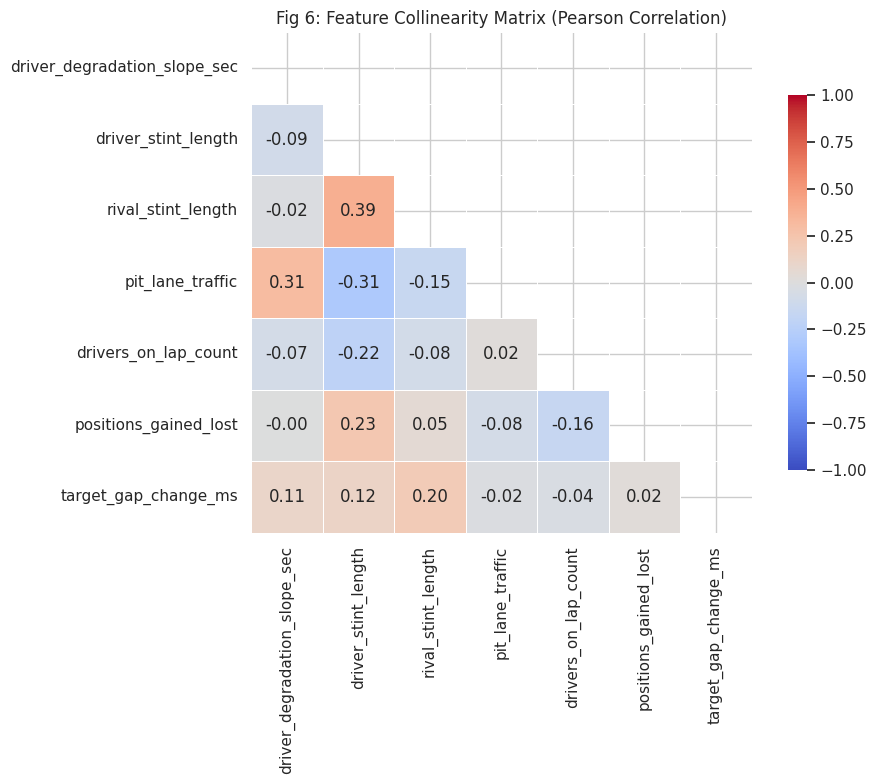

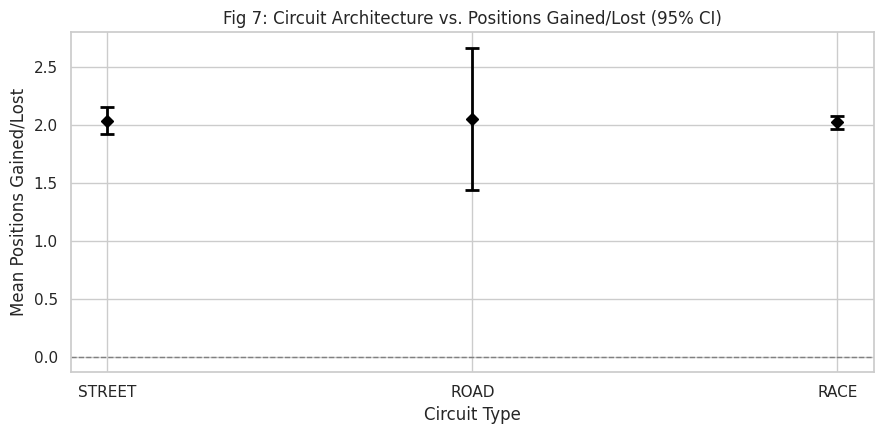

In [ ]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Initialize Spark Session & Ingest Parquet
# ==========================================
spark = SparkSession.builder \
    .appName("F1_EDA_Coursework") \
    .config("spark.sql.parquet.datetimeRebaseModeInRead", "CORRECTED") \
    .getOrCreate()

# Load the Parquet file via Spark
spark_df = spark.read.parquet(export_path)

# Set global visualization style
sns.set_theme(style="whitegrid", palette="muted")

# ==========================================
# Fig 1: Target Distribution & Kurtosis
# ==========================================
plt.figure(figsize=(10, 5))
# Calculate median distributively in Spark
median_val = spark_df.approxQuantile('target_gap_change_ms', [0.5], 0.01)[0]

# Collect full data for histogram rendering
fig1_data = spark_df.select('target_gap_change_ms').toPandas()

sns.histplot(fig1_data['target_gap_change_ms'], kde=True, bins=60, color='steelblue', edgecolor='black')
plt.axvline(median_val, color='darkred', linestyle='--', linewidth=2, label=f'Median: {median_val:.0f} ms')
plt.title("Fig 1: Net Gap Change Distribution (\u0394 Milliseconds)")
plt.xlabel("Target Gap Change (ms)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

# ==========================================
# Fig 2: Degradation Slope vs. Net Gap Change
# ==========================================
plt.figure(figsize=(10, 5))

# Filter out rows where the slope was artificially imputed as 0.0 before collecting
fig2_data = spark_df.filter(F.col('is_slope_missing') == 0) \
                    .select('driver_degradation_slope_sec', 'target_gap_change_ms') \
                    .toPandas()

sns.regplot(data=fig2_data, x='driver_degradation_slope_sec', y='target_gap_change_ms',
            scatter_kws={'alpha': 0.3, 's': 15, 'color': 'gray'}, line_kws={'color': 'darkred', 'linewidth': 2})
plt.title("Fig 2: Degradation Slope vs. Net Gap Change (Excluding Imputed Zeros)")
plt.xlabel("Driver Degradation Slope (Seconds/Lap)")
plt.ylabel("Target Gap Change (ms)")
plt.tight_layout()
plt.show()

# ==========================================
# Fig 3: Traffic Anomaly Analysis
# ==========================================
# Engineer the category in Spark before collecting
spark_df = spark_df.withColumn(
    'traffic_category',
    F.when(F.col('pit_lane_traffic') >= 3, '3+').otherwise(F.col('pit_lane_traffic').cast('string'))
)

fig3_data = spark_df.select('traffic_category', 'target_gap_change_ms').toPandas()

plt.figure(figsize=(10, 5))
sns.boxplot(data=fig3_data.sort_values('traffic_category'), x='traffic_category', y='target_gap_change_ms',
            palette="Greys", showfliers=True, flierprops=dict(marker='x', markersize=4, alpha=0.5))
plt.title("Fig 3: Pit Lane Traffic Density vs. Net Gap Change")
plt.xlabel("Concurrent Stops in Window (Traffic Category)")
plt.ylabel("Target Gap Change (ms)")
plt.tight_layout()
plt.show()

# ==========================================
# Fig 4: Data Imbalance & Edge Case Representation
# ==========================================
flags = ['is_prior_lap_missing', 'is_retired_after_pit', 'is_last_position', 'is_rival_retired_after_pit', 'is_slope_missing']

# Perform aggregation fully on the cluster
exprs = [F.sum(c).alias(c) for c in flags]
counts_df = spark_df.agg(*exprs).toPandas().iloc[0].sort_values(ascending=True)

plt.figure(figsize=(10, 5))
colors = ['lightgray'] * (len(counts_df) - 1) + ['darkred']
counts_df.plot(kind='barh', color=colors, edgecolor='black')
plt.title("Fig 4: Engineered Binary Flags Sparsity (Data Imbalance)")
plt.xlabel("Frequency Count")
plt.ylabel("Binary Feature")
plt.tight_layout()
plt.show()

# ==========================================
# Fig 5: Temporal Strategy Dynamics
# ==========================================
plt.figure(figsize=(10, 5))
# Filter directly in Spark before collecting
fig5_data = spark_df.filter(F.col('stop').isin([1, 2, 3])) \
                    .select('lap', 'stop') \
                    .toPandas()

for stop_num in [1, 2, 3]:
    subset = fig5_data[fig5_data['stop'] == stop_num]
    if not subset.empty:
        sns.kdeplot(subset['lap'], label=f'Stop {stop_num}', fill=True, alpha=0.3)
plt.title("Fig 5: Pit Stop Windows Across Race Laps")
plt.xlabel("Race Lap")
plt.ylabel("Density")
plt.xlim(0, 80)
plt.legend(title="Stop Sequence")
plt.tight_layout()
plt.show()

# ==========================================
# Fig 6: Feature Collinearity Matrix
# ==========================================
cols_for_corr = ['driver_degradation_slope_sec', 'driver_stint_length', 'rival_stint_length',
                 'pit_lane_traffic', 'drivers_on_lap_count', 'positions_gained_lost', 'target_gap_change_ms']

# Use Spark MLlib for distributed correlation computation
vector_col = "correlation_features"
assembler = VectorAssembler(inputCols=cols_for_corr, outputCol=vector_col, handleInvalid="skip")
vector_df = assembler.transform(spark_df).select(vector_col)

# Extract dense matrix and convert to Pandas for Seaborn
pearson_matrix = Correlation.corr(vector_df, vector_col).head()[0].toArray()
corr_pdf = pd.DataFrame(pearson_matrix, index=cols_for_corr, columns=cols_for_corr)

mask = np.triu(np.ones_like(corr_pdf, dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(corr_pdf, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            square=True, linewidths=.5, cbar_kws={"shrink": .75})
plt.title("Fig 6: Feature Collinearity Matrix (Pearson Correlation)")
plt.tight_layout()
plt.show()

# ==========================================
# Fig 7: Strategic Impact by Circuit Architecture
# ==========================================
# Group by the original retained categorical column in Spark, rather than Pandas dummy filters
circuit_stats = spark_df.filter(F.col('circuitType').isNotNull()) \
    .groupBy('circuitType') \
    .agg(
        F.mean('positions_gained_lost').alias('mean'),
        F.stddev('positions_gained_lost').alias('std'),
        F.count('positions_gained_lost').alias('count')
    ).toPandas()

# Calculate 95% CI locally
circuit_stats['ci95'] = 1.96 * (circuit_stats['std'] / np.sqrt(circuit_stats['count']))
circuit_stats = circuit_stats.fillna(0) # Handle single-record stddev NaNs

plt.figure(figsize=(9, 4.5))
x_indices = np.arange(len(circuit_stats))

plt.errorbar(x_indices, circuit_stats['mean'], yerr=circuit_stats['ci95'], fmt='D',
             color='black', ecolor='black', elinewidth=2, capsize=5, capthick=2)
plt.xticks(x_indices, circuit_stats['circuitType'])
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.ylabel("Mean Positions Gained/Lost")
plt.xlabel("Circuit Type")
plt.title("Fig 7: Circuit Architecture vs. Positions Gained/Lost (95% CI)")
plt.tight_layout()
plt.show()

# Terminate session
# spark.stop()

# Preprocessing after spliting data

Data spliting into training and testing

In [ ]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F

spark = SparkSession.builder.appName("F1_Temporal_Split").getOrCreate()
df = spark.read.parquet(export_path)

unique_races = df.select("raceId", "year", "round") \
                 .distinct() \
                 .orderBy("year", "round")

total_races = unique_races.count()
split_index = int(total_races * 0.80)

train_race_ids = unique_races.limit(split_index).select("raceId")

train_df = df.join(F.broadcast(train_race_ids), on="raceId", how="left_semi")
test_df = df.join(F.broadcast(train_race_ids), on="raceId", how="left_anti")

train_df = train_df.cache()
test_df = test_df.cache()

# Force the cache to materialize simultaneously with the count
total_rows = df.count()
train_rows = train_df.count()
test_rows = test_df.count()

print(f"Total Records: {total_rows}")
print(f"Training Set (Historical 80%): {train_rows} records ({train_rows/total_rows*100:.1f}%)")
print(f"Testing Set  (Future 20%):     {test_rows} records ({test_rows/total_rows*100:.1f}%)")

print("\nTraining Set Max Year/Round:")
train_df.agg(F.max("year"), F.max("round")).show()

print("Testing Set Min Year/Round:")
test_df.agg(F.min("year"), F.min("round")).show()

Total Records: 21770
Training Set (Historical 80%): 17658 records (81.1%)
Testing Set  (Future 20%):     4112 records (18.9%)

Training Set Max Year/Round:
+---------+----------+
|max(year)|max(round)|
+---------+----------+
|     2020|        21|
+---------+----------+

Testing Set Min Year/Round:
+---------+----------+
|min(year)|min(round)|
+---------+----------+
|     2020|         1|
+---------+----------+



Signed Log Transformation (Log-Modulus) to target_gap_change_sec

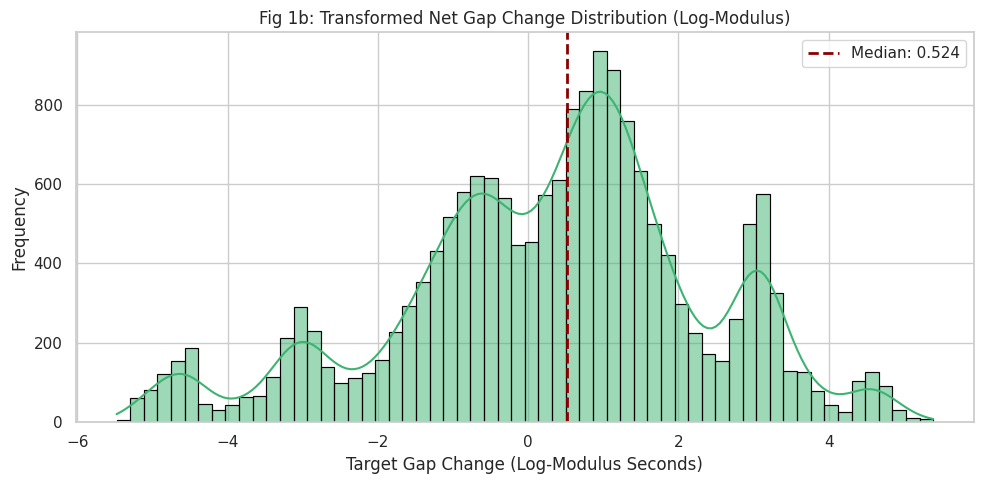

In [ ]:
import pyspark.sql.functions as F
import matplotlib.pyplot as plt
import seaborn as sns

# First, convert ms to seconds for easier interpretability
train_df = train_df.withColumn("target_gap_change_sec", F.col("target_gap_change_ms") / 1000.0)

# Apply the Log-Modulus formula: sign(x) * log(abs(x) + 1)
train_df = train_df.withColumn(
    "target_log_mod",
    F.signum(F.col("target_gap_change_sec")) * F.log1p(F.abs(F.col("target_gap_change_sec")))
)

# Visualize Transformed Distribution
plt.figure(figsize=(10, 5))

# Calculate the new median distributively
median_val_log = train_df.approxQuantile('target_log_mod', [0.5], 0.01)[0]

# Collect only the transformed column for plotting
fig1_log_data = train_df.select('target_log_mod').toPandas()

sns.histplot(fig1_log_data['target_log_mod'], kde=True, bins=60, color='mediumseagreen', edgecolor='black')
plt.axvline(median_val_log, color='darkred', linestyle='--', linewidth=2, label=f'Median: {median_val_log:.3f}')

plt.title("Fig 1b: Transformed Net Gap Change Distribution (Log-Modulus)")
plt.xlabel("Target Gap Change (Log-Modulus Seconds)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

Winsorization for target_gap_change_sec (target variable) due to contain of outliers

Winsorization Boundaries (ms): Lower=-131941, Upper=96620


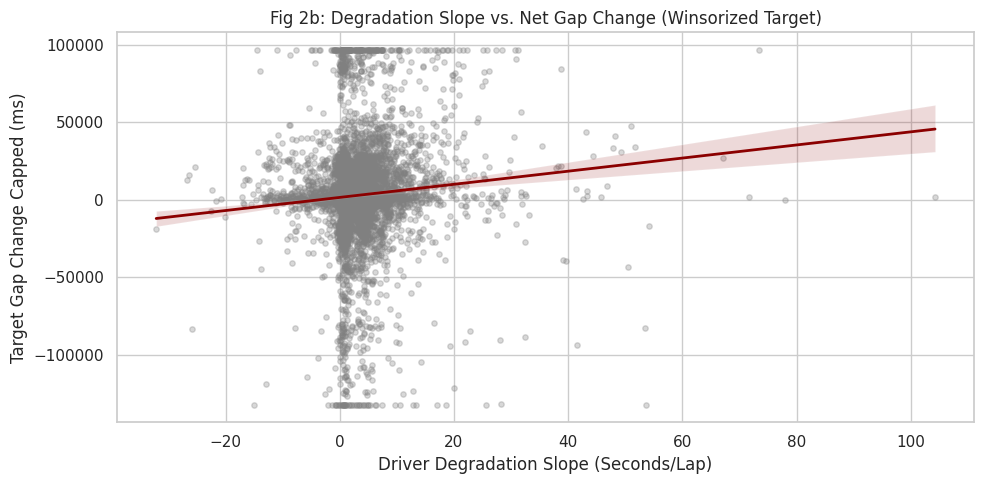

In [ ]:
import pyspark.sql.functions as F
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Calculate Training Percentiles
# ==========================================
# Calculate the 1st (0.01) and 99th (0.99) percentiles for the target variable
quantiles = train_df.approxQuantile("target_gap_change_ms", [0.01, 0.99], 0.001)
q_lower, q_upper = quantiles[0], quantiles[1]

print(f"Winsorization Boundaries (ms): Lower={q_lower:.0f}, Upper={q_upper:.0f}")

# ==========================================
# 2. Apply Capping (Winsorization)
# ==========================================
# Cap the Training Set
train_df = train_df.withColumn(
    "target_capped_ms",
    F.when(F.col("target_gap_change_ms") < q_lower, q_lower)
     .when(F.col("target_gap_change_ms") > q_upper, q_upper)
     .otherwise(F.col("target_gap_change_ms"))
)

# Cap the Test Set using the exact same boundaries learned from the Training Set
test_df = test_df.withColumn(
    "target_capped_ms",
    F.when(F.col("target_gap_change_ms") < q_lower, q_lower)
     .when(F.col("target_gap_change_ms") > q_upper, q_upper)
     .otherwise(F.col("target_gap_change_ms"))
)

# ==========================================
# 3. Visualize the Winsorized Result
# ==========================================
plt.figure(figsize=(10, 5))

# Filter out imputed zero slopes and collect to Pandas
fig2_data = train_df.filter(F.col('is_slope_missing') == 0) \
                    .select('driver_degradation_slope_sec', 'target_capped_ms') \
                    .toPandas()

# Generate the Regression Plot
sns.regplot(
    data=fig2_data,
    x='driver_degradation_slope_sec',
    y='target_capped_ms',
    scatter_kws={'alpha': 0.3, 's': 15, 'color': 'gray'},
    line_kws={'color': 'darkred', 'linewidth': 2}
)

plt.title("Fig 2b: Degradation Slope vs. Net Gap Change (Winsorized Target)")
plt.xlabel("Driver Degradation Slope (Seconds/Lap)")
plt.ylabel("Target Gap Change Capped (ms)")
plt.tight_layout()
plt.show()

RobustScaler for scaling only for continious data

In [ ]:
from pyspark.ml.linalg import Vectors, VectorUDT
import pyspark.sql.functions as F
from pyspark.ml.feature import RobustScaler, VectorAssembler, Bucketizer

# =================================================================
# 1. Column Definitions
# =================================================================
continuous_cols = [
    "year", "round", "courseLength", "turns", "laps", "scheduledLaps", "scheduledDistance",
    "lap", "stop", "driver_stint_length", "rival_stint_length",
    "driver_degradation_slope_sec", "pit_lane_traffic", "drivers_on_lap_count",
    "position_before_pit", "rival_position", "rival_gap_before_pit_ms", "positions_gained_lost",
    "gridPositionNumber", "qualificationPositionNumber", "gridPenalty"
]
binary_cols = [
    "gridPenaltyIsSpecialCode", "isPitLaneStart",
    "quali_NC", "quali_EX", "quali_DSQ", "quali_DNF", "quali_DNS",
    "is_freePractice1_held", "is_freePractice2_held", "is_freePractice3_held",
    "is_qualifying_held", "is_sprintQualifying_held", "is_sprintRace_held",
    "is_prior_lap_missing", "is_slope_missing", "is_last_position",
    "is_gap_before_missing", "is_gap_after_missing",
    "is_rival_stint_missing", "is_positions_gained_missing",
    "is_retired_after_pit", "is_rival_retired_after_pit"
]

categorical_vec_cols = ["qualifyingFormat_vec", "circuitType_vec", "direction_vec", "tyre_vec"]

# =================================================================
# 2. Vector Converter (String to DenseVector)
# =================================================================
@F.udf(returnType=VectorUDT())
def string_to_vector(vec_str):
    if not vec_str:
        return None
    clean_str = vec_str.replace('[', '').replace(']', '').strip()
    if not clean_str:
        return Vectors.dense([])
    return Vectors.dense([float(x.strip()) for x in clean_str.split(',')])

for col_name in categorical_vec_cols:
    train_df = train_df.withColumn(col_name, string_to_vector(F.col(col_name)))
    test_df = test_df.withColumn(col_name, string_to_vector(F.col(col_name)))

train_df = train_df.withColumn("target_gap_change_sec", F.col("target_gap_change_ms") / 1000.0)
test_df = test_df.withColumn("target_gap_change_sec", F.col("target_gap_change_ms") / 1000.0)

# =================================================================
# 3. Class Weighting Strategy (Handling Imbalance)
# =================================================================
# Define splits for target bucketing
splits = [-float("inf"), 0.0, float("inf")]

bucketizer = Bucketizer(
    splits=splits,
    inputCol="target_gap_change_sec", # Ensure this column was created prior to this cell
    outputCol="target_label"
)

# Apply bucketizer
train_df = bucketizer.transform(train_df)
test_df = bucketizer.transform(test_df)

# Calculate class frequencies strictly on the TRAINING set
total_count = train_df.count()
class_counts = train_df.groupBy("target_label").count()
num_classes = class_counts.count()

# Calculate Inverse Frequency Weights to balance the classes
class_weights = class_counts.withColumn(
    "weight", F.lit(total_count) / (F.lit(num_classes) * F.col("count"))
).drop("count")

# Join weights back using a Broadcast join to optimize cluster performance
train_df = train_df.join(F.broadcast(class_weights), on="target_label", how="left")
test_df = test_df.join(F.broadcast(class_weights), on="target_label", how="left")

# =================================================================
# 4. Continuous Feature Scaling
# =================================================================
cont_assembler = VectorAssembler(inputCols=continuous_cols, outputCol="raw_continuous", handleInvalid="skip")
train_cont = cont_assembler.transform(train_df)
test_cont = cont_assembler.transform(test_df)

scaler = RobustScaler(inputCol="raw_continuous", outputCol="scaled_continuous", withCentering=True, withScaling=True)
scaler_model = scaler.fit(train_cont)

train_scaled_cont = scaler_model.transform(train_cont)
test_scaled_cont = scaler_model.transform(test_cont)

# =================================================================
# 5. Final Feature Assembly
# =================================================================
final_feature_cols = ["scaled_continuous"] + categorical_vec_cols + binary_cols
final_assembler = VectorAssembler(inputCols=final_feature_cols, outputCol="features", handleInvalid="skip")

train_final = final_assembler.transform(train_scaled_cont)
test_final = final_assembler.transform(test_scaled_cont)

# Verification: Show the final assembled vector, the label, and the computed weight
train_final.select("features", "target_label", "weight").show(5, truncate=False)

+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------------+------------------+
|features                                                                                                                                                                                                                                                                                                                                                                                                                 |target_label|weight            |
+---------------------------------------------------------------------------------------------------------------

# Model training

Random forest model train

In [ ]:
from pyspark.ml.regression import RandomForestRegressor

train_final = train_final.cache()
test_final = test_final.cache()

rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="target_gap_change_sec",
    weightCol="weight",
    predictionCol="rf_prediction",
    numTrees=100,
    maxDepth=10,
    seed=42
)

rf_model = rf.fit(train_final)

test_predictions = rf_model.transform(test_final)

GBT model train

In [ ]:
from pyspark.ml.regression import GBTRegressor

train_final = train_final.cache()
test_final = test_final.cache()

gbt = GBTRegressor(
    featuresCol="features",
    labelCol="target_gap_change_sec",
    weightCol="weight",
    predictionCol="gbt_prediction",
    maxIter=100,
    maxDepth=5,
    stepSize=0.1,
    seed=42
)

print("Initiating Gradient Boosted Trees training sequence...")
gbt_model = gbt.fit(train_final)
print("Training complete.")

gbt_predictions = gbt_model.transform(test_final)

Initiating Gradient Boosted Trees training sequence...
Training complete.


# Evaluations

## Random forest

Random forest evaluations - common

In [ ]:
from pyspark.ml.evaluation import RegressionEvaluator
import pyspark.sql.functions as F
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import pandas as pd

#Initialize Evaluators
eval_rmse = RegressionEvaluator(labelCol="target_gap_change_sec", predictionCol="rf_prediction", metricName="rmse")
eval_mse = RegressionEvaluator(labelCol="target_gap_change_sec", predictionCol="rf_prediction", metricName="mse")
eval_r2 = RegressionEvaluator(labelCol="target_gap_change_sec", predictionCol="rf_prediction", metricName="r2")

#Compute Base Metrics
rmse = eval_rmse.evaluate(test_predictions)
mse = eval_mse.evaluate(test_predictions)
r2 = eval_r2.evaluate(test_predictions)

#Calculate Adjusted R-Squared
n = test_predictions.count()
p = len(final_feature_cols)
adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Squared Error (MSE):       {mse:.4f}")
print(f"R-Squared (R2):                 {r2:.4f}")
print(f"Adjusted R-Squared:             {adj_r2:.4f}\n")

test_predictions = test_predictions.withColumn(
    "predicted_label",
    F.when(F.col("rf_prediction") > 0.0, 1.0).otherwise(0.0)
)

results_df = test_predictions.select("target_label", "predicted_label", "rf_prediction").toPandas()

y_true = results_df["target_label"]
y_pred_class = results_df["predicted_label"]
y_pred_continuous = results_df["rf_prediction"]

# print("Confusion Matrix:")
# print(confusion_matrix(y_true, y_pred_class))

print("\nClassification Report: ")
print(classification_report(y_true, y_pred_class))

auc = roc_auc_score(y_true, y_pred_continuous)
print(f"AUC - ROC: {auc:.4f}")

Root Mean Squared Error (RMSE): 15.6597
Mean Squared Error (MSE):       245.2254
R-Squared (R2):                 0.7837
Adjusted R-Squared:             0.7823


Classification Report: 
              precision    recall  f1-score   support

         0.0       0.66      0.58      0.62       923
         1.0       0.88      0.91      0.90      3189

    accuracy                           0.84      4112
   macro avg       0.77      0.75      0.76      4112
weighted avg       0.83      0.84      0.83      4112

AUC - ROC: 0.7478


Random forest - confusion matrix

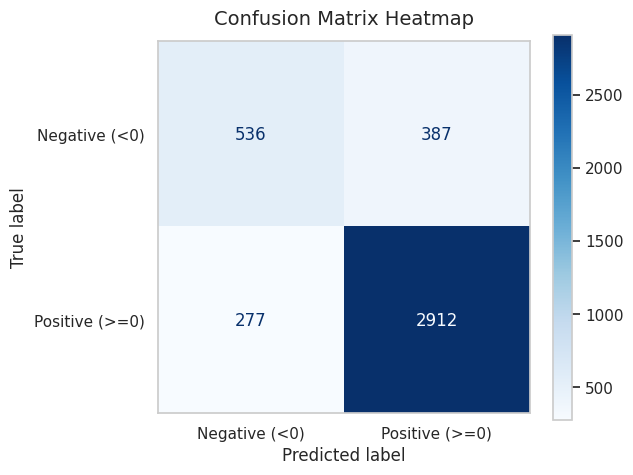

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_true, y_pred_class),
    display_labels=["Negative (<0)", "Positive (>=0)"]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap="Blues", values_format="d", ax=ax)
plt.title("Confusion Matrix Heatmap", fontsize=14, pad=12)
plt.grid(False)
plt.show()

Random forest evaluations - Accuracy VS Balanced Accuracy

In [ ]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score

# Assuming y_true and y_pred_class are already extracted as Pandas series
normal_acc = accuracy_score(y_true, y_pred_class)
balanced_acc = balanced_accuracy_score(y_true, y_pred_class)

print(f"Normal Accuracy:   {normal_acc:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")

Normal Accuracy:   0.8385
Balanced Accuracy: 0.7469


Random forest evaluations - Matthews correlation

In [ ]:
from sklearn.metrics import matthews_corrcoef

mcc = matthews_corrcoef(y_true, y_pred_class)
print(f"Matthews Correlation Coefficient: {mcc:.4f}")

Matthews Correlation Coefficient: 0.5174


Random forest evaluations - Residual error destribution

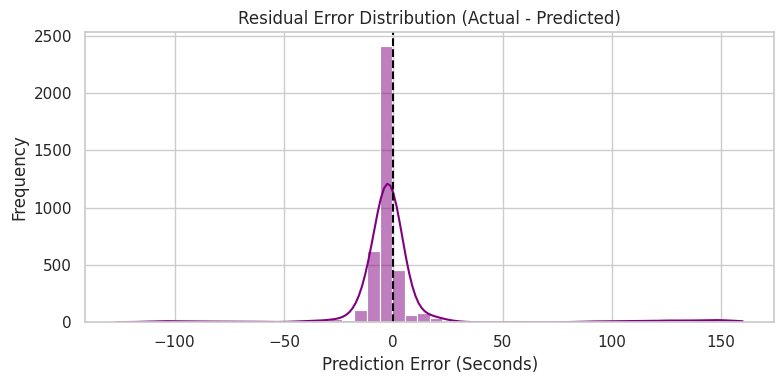

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate exact error in seconds
results_df['residual'] = results_df['target_label'] - results_df['rf_prediction']

plt.figure(figsize=(8, 4))
sns.histplot(results_df['residual'], bins=50, kde=True, color='purple')
plt.axvline(0, color='black', linestyle='--')
plt.title("Residual Error Distribution (Actual - Predicted)")
plt.xlabel("Prediction Error (Seconds)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Random forest evaluations - Heteroscedasticity Analysis (Residual vs. Predicted Plot)

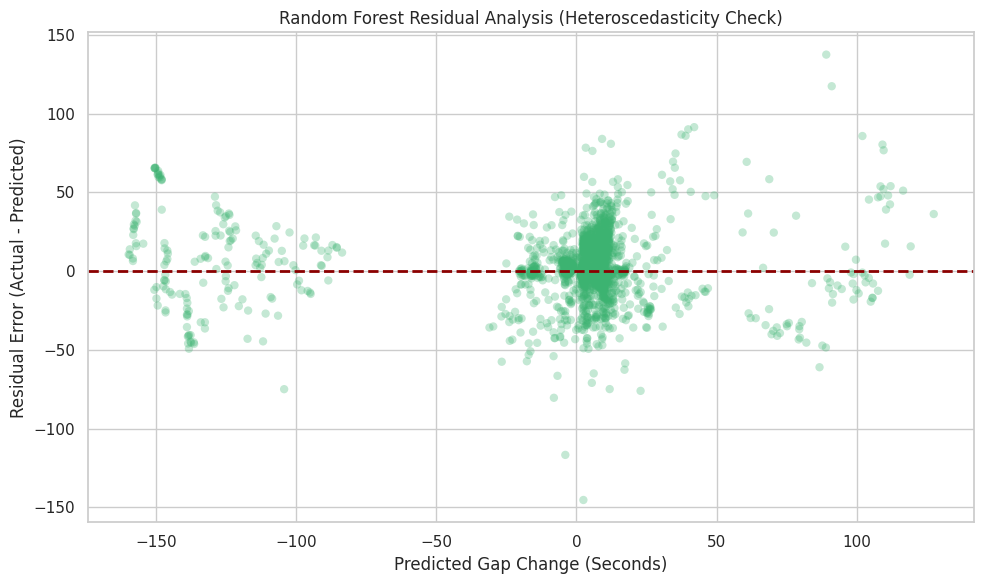

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

rf_residual_df = test_predictions.select("target_gap_change_sec", "rf_prediction").toPandas()

# Calculate the error (Actual - Predicted)
rf_residual_df['residual'] = rf_residual_df['target_gap_change_sec'] - rf_residual_df['rf_prediction']

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=rf_residual_df,
    x='rf_prediction',
    y='residual',
    alpha=0.3,
    color='mediumseagreen',
    edgecolor='none'
)
plt.axhline(0, color='darkred', linestyle='--', linewidth=2)
plt.title("Random Forest Residual Analysis (Heteroscedasticity Check)")
plt.xlabel("Predicted Gap Change (Seconds)")
plt.ylabel("Residual Error (Actual - Predicted)")
plt.tight_layout()
plt.show()

## Gradient Boosted Trees

GBT Evaluations - common

In [ ]:
from pyspark.ml.evaluation import RegressionEvaluator
import pyspark.sql.functions as F
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, balanced_accuracy_score
import pandas as pd

evaluator_rmse_gbt = RegressionEvaluator(labelCol="target_gap_change_sec", predictionCol="gbt_prediction", metricName="rmse")
evaluator_mse_gbt = RegressionEvaluator(labelCol="target_gap_change_sec", predictionCol="gbt_prediction", metricName="mse")
evaluator_r2_gbt = RegressionEvaluator(labelCol="target_gap_change_sec", predictionCol="gbt_prediction", metricName="r2")

gbt_rmse = evaluator_rmse_gbt.evaluate(gbt_predictions)
gbt_mse = evaluator_mse_gbt.evaluate(gbt_predictions)
gbt_r2 = evaluator_r2_gbt.evaluate(gbt_predictions)

# Calculate Adjusted R-Squared
n = gbt_predictions.count()
p = len(final_feature_cols)
gbt_adj_r2 = 1 - ((1 - gbt_r2) * (n - 1) / (n - p - 1))

print(f"Root Mean Squared Error (RMSE): {gbt_rmse:.3f} seconds")
print(f"Mean Squared Error (MSE):       {gbt_mse:.3f} seconds")
print(f"R-Squared (R2):                 {gbt_r2:.4f}")
print(f"Adjusted R-Squared:             {gbt_adj_r2:.4f}\n")


gbt_predictions = gbt_predictions.withColumn(
    "predicted_label",
    F.when(F.col("gbt_prediction") > 0.0, 1.0).otherwise(0.0)
)

results_df = gbt_predictions.select("target_label", "predicted_label", "gbt_prediction").toPandas()

y_true = results_df["target_label"]
y_pred_class = results_df["predicted_label"]
y_pred_continuous = results_df["gbt_prediction"]

#Classification Metrics
normal_acc = accuracy_score(y_true, y_pred_class)
balanced_acc = balanced_accuracy_score(y_true, y_pred_class)
auc = roc_auc_score(y_true, y_pred_continuous)

print(f"Normal Accuracy:   {normal_acc:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print(f"AUC - ROC:         {auc:.4f}\n")

print("\nClassification Report:")
print(classification_report(y_true, y_pred_class))

--- REGRESSION METRICS ---
Root Mean Squared Error (RMSE): 16.130 seconds
Mean Squared Error (MSE):       260.193 seconds
R-Squared (R2):                 0.7705
Adjusted R-Squared:             0.7690

--- CLASSIFICATION METRICS ---
Normal Accuracy:   0.7772
Balanced Accuracy: 0.7247
AUC - ROC:         0.7391

Confusion Matrix:
[[ 581  342]
 [ 574 2615]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.50      0.63      0.56       923
         1.0       0.88      0.82      0.85      3189

    accuracy                           0.78      4112
   macro avg       0.69      0.72      0.71      4112
weighted avg       0.80      0.78      0.79      4112



GBT - Confusion matrix

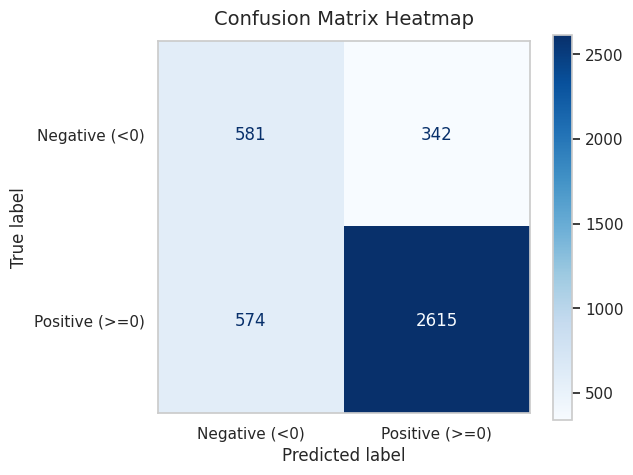

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_true, y_pred_class),
    display_labels=["Negative (<0)", "Positive (>=0)"]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap="Blues", values_format="d", ax=ax)
plt.title("Confusion Matrix Heatmap", fontsize=14, pad=12)
plt.grid(False)
plt.show()

GTB evaluation - Heteroscedasticity Analysis (Residual vs. Predicted Plot)

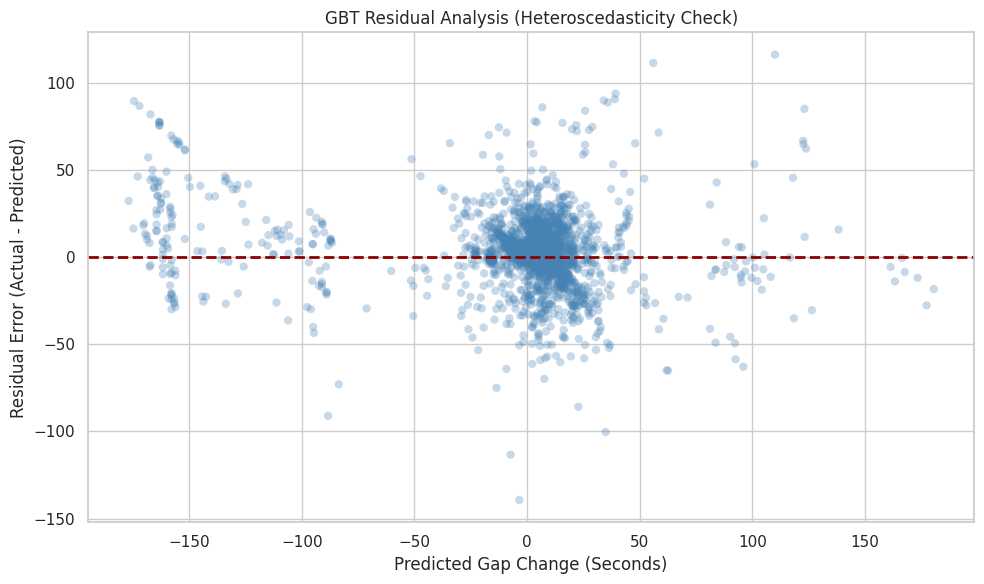

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

residual_df = gbt_predictions.select("target_gap_change_sec", "gbt_prediction").toPandas()

residual_df['residual'] = residual_df['target_gap_change_sec'] - residual_df['gbt_prediction']

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=residual_df,
    x='gbt_prediction',
    y='residual',
    alpha=0.3,
    color='steelblue',
    edgecolor='none'
)
plt.axhline(0, color='darkred', linestyle='--', linewidth=2)
plt.title("GBT Residual Analysis (Heteroscedasticity Check)")
plt.xlabel("Predicted Gap Change (Seconds)")
plt.ylabel("Residual Error (Actual - Predicted)")
plt.tight_layout()
plt.show()

GTB model - Residual Error Distribution

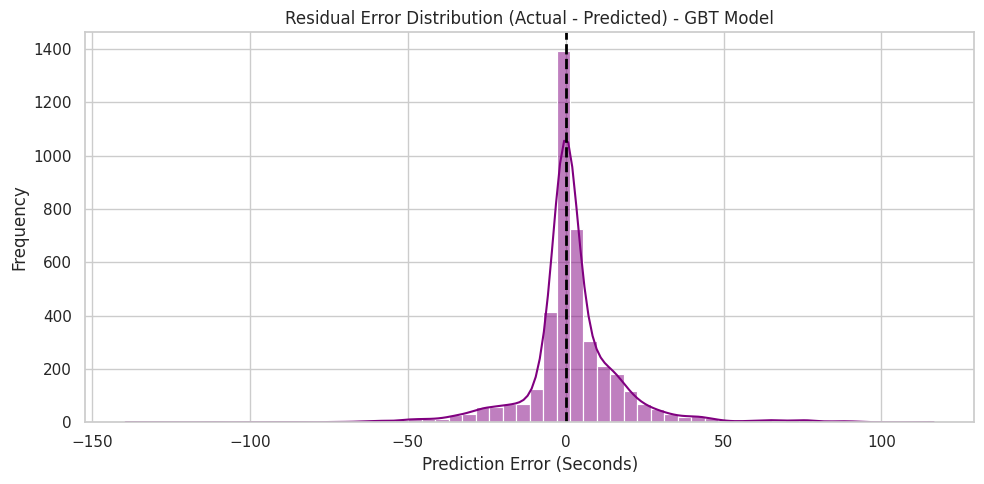

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

gbt_results_df = gbt_predictions.select("target_gap_change_sec", "gbt_prediction").toPandas()

gbt_results_df['residual'] = gbt_results_df['target_gap_change_sec'] - gbt_results_df['gbt_prediction']

plt.figure(figsize=(10, 5))
sns.histplot(
    gbt_results_df['residual'],
    bins=60,
    kde=True,
    color='purple'
)
plt.axvline(0, color='black', linestyle='--', linewidth=2)

# 4. Format the chart
plt.title("Residual Error Distribution (Actual - Predicted) - GBT Model")
plt.xlabel("Prediction Error (Seconds)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()